In [33]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils
import TCR_embedings

In [34]:
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

In [35]:
%cd "/ix1/ylee/Yifan_Zhang/Code_data/external"

/ix1/ylee/Yifan_Zhang/Code_data/external


In [36]:
mdata = mu.read("merged_EAE.h5mu")

In [37]:
mdata['airr'].obs['GSE'] = mdata.obs['GSE']

# embed TCR AA into vector

In [38]:
tcr_aa_obs = ['VDJ_1_cdr3_aa', 'VJ_1_cdr3_aa']
tcr_cat_features = ['VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call']
tcr_num_features = []

In [39]:
# Atchley factors for the 20 amino acids
atchley_factors = {
    'A': [ 0.591, -1.302, -0.733,  1.570, -0.146],  # Alanine
    'R': [ 1.538,  0.055,  1.502,  0.440,  2.897],  # Arginine
    'N': [ 0.945,  0.828,  1.299, -0.169,  0.933],  # Asparagine
    'D': [ 1.050,  0.302, -3.656, -0.259, -3.242],  # Aspartic acid
    'C': [-1.343,  0.465, -0.862, -1.020, -0.255],  # Cysteine
    'Q': [ 0.931,  0.179, -3.005, -0.503, -1.853],  # Glutamine
    'E': [ 1.357,  0.113, -3.242, -0.339, -2.192],  # Glutamic acid
    'G': [ 0.384,  1.652,  1.330,  1.045,  2.064],  # Glycine
    'H': [ 0.336, -0.417, -1.673, -1.474, -0.078],  # Histidine
    'I': [-1.239, -0.547,  2.131,  0.393,  0.816],  # Isoleucine
    'L': [-1.019, -0.987, -1.505,  1.266, -0.912],  # Leucine
    'K': [ 1.831, -0.561,  0.533, -0.277,  1.648],  # Lysine
    'M': [-0.663, -1.524,  2.219, -1.005,  1.212],  # Methionine
    'F': [-1.006, -0.590,  1.891, -0.397,  0.412],  # Phenylalanine
    'P': [ 0.189,  2.081, -1.628,  0.421, -1.392],  # Proline
    'S': [ 0.228,  1.399, -4.760,  0.670, -2.647],  # Serine
    'T': [ 0.032,  2.213, -1.455,  0.311, -0.259],  # Threonine
    'W': [-0.595,  0.009,  0.672, -2.128, -0.184],  # Tryptophan
    'Y': [ 0.260,  0.830,  3.097, -0.838,  1.512],  # Tyrosine
    'V': [-1.337, -0.279, -0.544,  1.242, -1.262],  # Valine
}


In [40]:
# Vectorize each TCR amino acid column and compute composition & length
for aa_col in tcr_aa_obs:
    # 1. Atchley factor encoding
    encoded = TCR_embedings.vectorize_tcr_column(mdata, aa_col, atchley_factors)
    key_name = f'X_{aa_col}_atchley'
    mdata.obsm[key_name] = encoded
    print(f"Stored {aa_col} Atchley vectors in mdata.obsm['{key_name}'] with shape {encoded.shape}")
    
    # 2. AA composition (percentage of each of 20 AAs)
    aa_comp = TCR_embedings.compute_aa_composition_matrix(mdata, aa_col)
    comp_key = f'X_{aa_col}_composition'
    mdata.obsm[comp_key] = aa_comp
    print(f"Stored {aa_col} AA composition in mdata.obsm['{comp_key}'] with shape {aa_comp.shape}")
    
    # 3. Sequence length
    lengths = TCR_embedings.compute_sequence_lengths(mdata, aa_col)
    len_key = f'{aa_col}_length'
    mdata.obs[len_key] = lengths
    print(f"Stored {aa_col} lengths in mdata.obs['{len_key}']\n")


Stored VDJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VDJ_1_cdr3_aa_atchley'] with shape (142936, 140)
Stored VDJ_1_cdr3_aa AA composition in mdata.obsm['X_VDJ_1_cdr3_aa_composition'] with shape (142936, 20)
Stored VDJ_1_cdr3_aa lengths in mdata.obs['VDJ_1_cdr3_aa_length']

Stored VJ_1_cdr3_aa Atchley vectors in mdata.obsm['X_VJ_1_cdr3_aa_atchley'] with shape (142936, 640)
Stored VJ_1_cdr3_aa AA composition in mdata.obsm['X_VJ_1_cdr3_aa_composition'] with shape (142936, 20)
Stored VJ_1_cdr3_aa lengths in mdata.obs['VJ_1_cdr3_aa_length']



In [41]:
# One-hot encode all categorical TCR features and concatenate
cat_encoded_list = []
for cat_col in tcr_cat_features:
    encoded = TCR_embedings.onehot_encode_categorical(mdata, cat_col)
    # cat_encoded_list.append(encoded)
    mdata.obsm[cat_col] = encoded

# Concatenate all one-hot encoded vectors
# tcr_cat_onehot = np.concatenate(cat_encoded_list, axis=1)

mdata_ori = mdata.copy()


VDJ_1_j_call: 12 unique categories + 1 unknown = 13 dimensions
VDJ_1_v_call: 24 unique categories + 1 unknown = 25 dimensions
VJ_1_j_call: 43 unique categories + 1 unknown = 44 dimensions
VJ_1_v_call: 105 unique categories + 1 unknown = 106 dimensions


# Subsets

#### only cloned TCRs

In [42]:
mdata_cloned = mdata[mdata['airr'].obs['clone_id_size'].fillna(0).astype('int') > 1].copy()

#### select only one cell from each clonotype

In [43]:
# Randomly keep one cell per clone_id within each GSE subset
airr = mdata_cloned['airr']
print(f"Original number of cells: {airr.n_obs}")

# Store indices to keep
indices_to_keep = []

# Group by GSE
for gse in airr.obs['GSE'].unique():
    # Get cells for this GSE
    gse_mask = airr.obs['GSE'] == gse
    gse_obs = airr.obs[gse_mask]
    
    print(f"\nGSE: {gse} - Original cells: {len(gse_obs)}")
    
    # For each clone_id in this GSE, randomly select one cell
    for clone_id in gse_obs['clone_id'].unique():
        clone_cells = gse_obs[gse_obs['clone_id'] == clone_id]
        # Randomly sample one cell from this clone
        selected_idx = clone_cells.sample(n=1, random_state=42).index[0]
        indices_to_keep.append(selected_idx)
    
    print(f"GSE: {gse} - After sampling: {len(gse_obs['clone_id'].unique())} cells (one per clone)")

# Create subset with selected cells
mdata_cloned_oneCell = mdata[indices_to_keep].copy()


Original number of cells: 67053

GSE: LEE - Original cells: 6310
GSE: LEE - After sampling: 1689 cells (one per clone)

GSE: GSE156718 - Original cells: 3182
GSE: GSE156718 - After sampling: 1111 cells (one per clone)

GSE: GSE182747 - Original cells: 26215
GSE: GSE182747 - After sampling: 3542 cells (one per clone)

GSE: GSE293883 - Original cells: 2483
GSE: GSE293883 - After sampling: 652 cells (one per clone)

GSE: GSE178085 - Original cells: 511
GSE: GSE178085 - After sampling: 2 cells (one per clone)

GSE: GSE188320 - Original cells: 28352
GSE: GSE188320 - After sampling: 4549 cells (one per clone)


## select subset

In [67]:
mdata = mdata_cloned
mdata

MuData object with n_obs × n_vars = 67053 × 5000
  obs:	'GSE', 'GSM', 'VDJ_1_cdr3_aa', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_cdr3_aa', 'VJ_1_j_call', 'VJ_1_v_call', 'cell_type', 'condition', 'sample_id', 'state', 'VDJ_1_cdr3_aa_length', 'VJ_1_cdr3_aa_length'
  obsm:	'X_VDJ_1_cdr3_aa_atchley', 'X_VDJ_1_cdr3_aa_composition', 'X_VJ_1_cdr3_aa_atchley', 'X_VJ_1_cdr3_aa_composition', 'VDJ_1_j_call', 'VDJ_1_v_call', 'VJ_1_j_call', 'VJ_1_v_call'
  2 modalities
    gex:	67053 x 5000
      obs:	'sample_id', 'date', 'tissue', 'sample', 'mouse_BC', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state', 'TCR_clonotype_frequency', 'condition', 'batch', 'leiden', 'GSE'
      var:	'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
      uns:	'GSE_colors', 'X_umap_harmony', 'cell_type_colors', 'hvg', 'leiden', 'neighbors', 'neighbors_harmony', 'pca', 'state_colors', 'tissue_colors', 'umap'
      obsm:	'X_pca', 'X_pca_harmony', 'X_umap', 'X_umap_harmony'
      varm:	'PCs'
      obsp:	'connectivities', 'distances', 'neighbors_harmony_connectivities', 'neighbors_harmony_distances'
    airr:	67053 x 0
      obs:	'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion', 'sample', 'tissue', 'condition', 'GSE'
      obsm:	'airr', 'chain_indices'

In [68]:
mdata['gex'].obs['tissue'].value_counts()

tissue
CNS       33526
Spleen    11190
COL        3940
PP         3495
SI         2924
DLN        1902
MLN        1122
iLN         940
mLN         728
Name: count, dtype: int64

# clusters

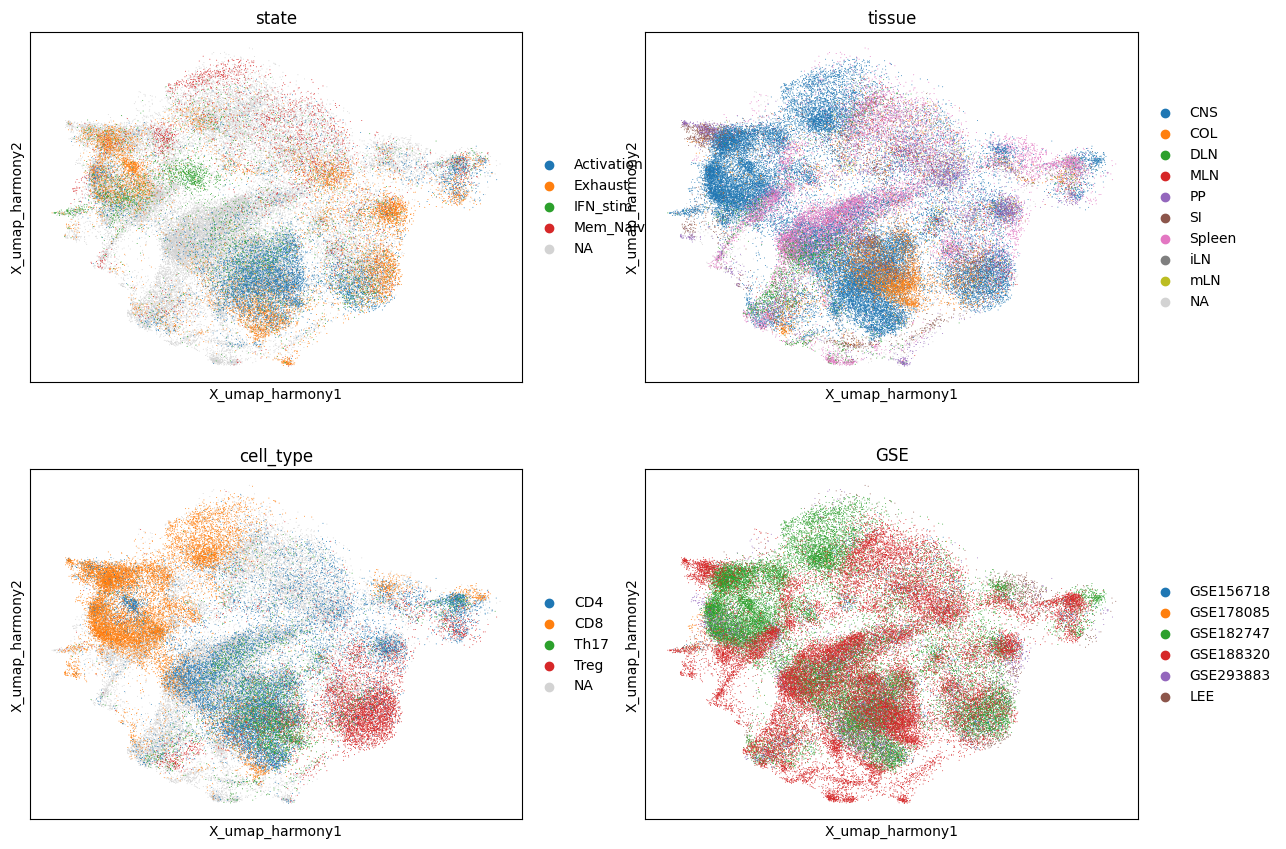

In [69]:
Batch_corrected = True
gene_PCA = 'X_pca_harmony' if Batch_corrected else 'X_pca'
gene_Umap = 'X_umap_harmony' if Batch_corrected else 'X_umap'


sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
                color=['state', 'tissue', 'cell_type', 'GSE'], ncols=2,)

In [70]:
top_n = 20
sc.tl.rank_genes_groups(mdata["gex"], groupby='tissue', groups = ['CNS'], reference='rest',
                        n_genes = top_n, method='t-test')
rank_df = sc.get.rank_genes_groups_df(mdata["gex"], None)


In [71]:
rank_df.head(5)

,names,scores,logfoldchanges,pvals,pvals_adj
0,Gm10076,318.569702,5.695702,0.0,0.0
1,Rpl9-ps6,314.695862,6.294747,0.0,0.0
2,Rpl10-ps3,280.293060,4.997414,0.0,0.0
3,Rack1,263.304077,3.752137,0.0,0.0
4,Uba52,241.285339,3.070042,0.0,0.0


#### train test split by samples

In [72]:
# select data sets as test 
test_ids = ['LEE']
mdata.obs.loc[mdata.obs['GSE'].isin(test_ids), 'set'] = 'test'
mdata.obs.loc[~mdata.obs['GSE'].isin(test_ids), 'set'] = 'train'
mdata.obs['set'].value_counts()

set
train    60743
test      6310
Name: count, dtype: int64

# Prepare feature array

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA

In [74]:
arrs_tcr = []
for key, value in mdata.obsm.items():
    arrs_tcr.append(value)

view_tcr = np.concatenate(arrs_tcr, axis=1)
view_tcr = np.concatenate([view_tcr, mdata.obs['VDJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1),
                           mdata.obs['VJ_1_cdr3_aa_length'].to_numpy().reshape(-1, 1)],  axis=1)

scaler = StandardScaler()
view_tcr = scaler.fit_transform(view_tcr)

# biased logistic regression

In [75]:
# Logistic Regression: predict CNS vs rest using TCR features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Create binary label: CNS vs rest
y = (mdata['gex'].obs['tissue'] == 'CNS').astype(int)

# Split data by fractions
# X_train, X_test, y_train, y_test = train_test_split(view_tcr, y, test_size=0.2, random_state=42, stratify=y)

# Split data based on mdata.obs['set']
train_mask = mdata.obs['set'] == 'train'
test_mask = mdata.obs['set'] == 'test'

X_train = view_tcr[train_mask]
X_test = view_tcr[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Apply RandomOverSampler to balance classes
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train)
# X_test, y_test = ros.fit_resample(X_test, y_test)

print(f"\nAfter oversampling:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# Predictions
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

# Evaluation
print(f"\n{'='*60}")
print("Performance on Test Set:")
print(f"{'='*60}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-CNS', 'CNS']))

print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Training set: 60743 samples
Test set: 6310 samples

After oversampling:
Training set: 62340 samples
Test set: 6310 samples

Performance on Test Set:
Accuracy: 0.5252
ROC AUC: 0.5278

Classification Report:
              precision    recall  f1-score   support

     Non-CNS       0.39      0.49      0.43      2357
         CNS       0.64      0.55      0.59      3953

    accuracy                           0.53      6310
   macro avg       0.52      0.52      0.51      6310
weighted avg       0.55      0.53      0.53      6310


Confusion Matrix:
[[1152 1205]
 [1791 2162]]


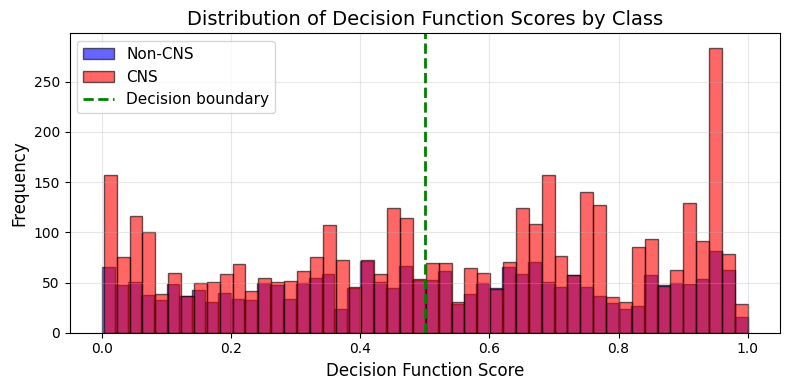

Non-CNS scores - Mean: 0.5089, Std: 0.2856
CNS scores - Mean: 0.5345, Std: 0.3011
KS statistic: 0.08677254730782924 p-value: 3.9924427972000644e-10


In [76]:
# Plot distribution of decision function for both classes
# score_p = lr_model.decision_function(X_test)
# decision_scores = (score_p - np.mean(score_p)) / np.std(score_p)

decision_scores = y_pred_proba

# Separate scores by class
scores_non_cns = decision_scores[y_test == 0]
scores_cns = decision_scores[y_test == 1]

# Create the plot
plt.figure(figsize=(8,4))
plt.hist(scores_non_cns, bins=50, alpha=0.6, label='Non-CNS', color='blue', edgecolor='black')
plt.hist(scores_cns, bins=50, alpha=0.6, label='CNS', color='red', edgecolor='black')
plt.axvline(x=0.5, color='green', linestyle='--', linewidth=2, label='Decision boundary')
plt.xlabel('Decision Function Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Decision Function Scores by Class', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"Non-CNS scores - Mean: {scores_non_cns.mean():.4f}, Std: {scores_non_cns.std():.4f}")
print(f"CNS scores - Mean: {scores_cns.mean():.4f}, Std: {scores_cns.std():.4f}")
from scipy.stats import ks_2samp
stat, p = ks_2samp(scores_non_cns, scores_cns)
print("KS statistic:", stat, "p-value:", p)

# Unbiased CCA

In [77]:
# Perform Canonical Correlation Analysis separately on train and test sets
view_gene = mdata['gex'].obsm[gene_PCA]
view_gene_scaled = scaler.fit_transform(view_gene)

# Split data based on mdata.obs['set']
train_mask = mdata.obs['set'] == 'train'
test_mask = mdata.obs['set'] == 'test'

view_gene_train = view_gene_scaled[train_mask]
view_gene_test = view_gene_scaled[test_mask]
view_tcr_train = view_tcr[train_mask]
view_tcr_test = view_tcr[test_mask]

print(f"Train set: {view_gene_train.shape[0]} samples")
print(f"Test set: {view_gene_test.shape[0]} samples")

# Fit CCA on train set
cca = CCA(n_components=4)
view_gene_c_train, view_tcr_c_train = cca.fit_transform(view_gene_train, view_tcr_train)

# Transform test set using fitted CCA
view_gene_c_test, view_tcr_c_test = cca.transform(view_gene_test, view_tcr_test)

print(f"\nTrain canonical variates shape: {view_gene_c_train.shape}")
print(f"Test canonical variates shape: {view_gene_c_test.shape}")

# Combine for full dataset storage
view_gene_c = np.zeros((mdata.n_obs, 4))
view_tcr_c = np.zeros((mdata.n_obs, 4))
view_gene_c[train_mask] = view_gene_c_train
view_gene_c[test_mask] = view_gene_c_test
view_tcr_c[train_mask] = view_tcr_c_train
view_tcr_c[test_mask] = view_tcr_c_test

Train set: 60743 samples
Test set: 6310 samples

Train canonical variates shape: (60743, 4)
Test canonical variates shape: (6310, 4)


In [78]:
# weights
x_loadings_df = pd.DataFrame(cca.x_loadings_)
print(x_loadings_df.shape)

# There is a corresponding matrix for Y
y_loadings_df = pd.DataFrame(cca.y_loadings_)
print(y_loadings_df.shape)

(50, 4)
(1012, 4)


In [79]:
# Calculate the correlations separately for train and test sets
correlations_train = []
correlations_test = []
cv_list = []

print("Canonical Correlations Comparison:")
print("="*60)
print(f"{'Component':<15} {'Train Corr':<15} {'Test Corr':<15} {'Difference':<15}")
print("="*60)

for i in range(cca.x_loadings_.shape[1]):
  # Calculate correlation for train set
  corr_train = np.corrcoef(view_gene_c_train[:, i], view_tcr_c_train[:, i])[0, 1]
  correlations_train.append(corr_train)
  
  # Calculate correlation for test set
  corr_test = np.corrcoef(view_gene_c_test[:, i], view_tcr_c_test[:, i])[0, 1]
  correlations_test.append(corr_test)
  
  # Calculate difference
  diff = corr_train - corr_test
  
  print(f"Component {i+1:<6} {corr_train:<15.4f} {corr_test:<15.4f} {diff:<15.4f}")
  
  # Store CV scores in mdata
  mdata['gex'].obs['CV_score_'+str(i)] = view_tcr_c[:, i]
  cv_list.append('CV_score_'+str(i))


Canonical Correlations Comparison:
Component       Train Corr      Test Corr       Difference     
Component 1      0.5465          0.3605          0.1861         
Component 2      0.4389          0.1956          0.2433         
Component 3      0.4154          0.0780          0.3374         
Component 4      0.3820          -0.0087         0.3907         


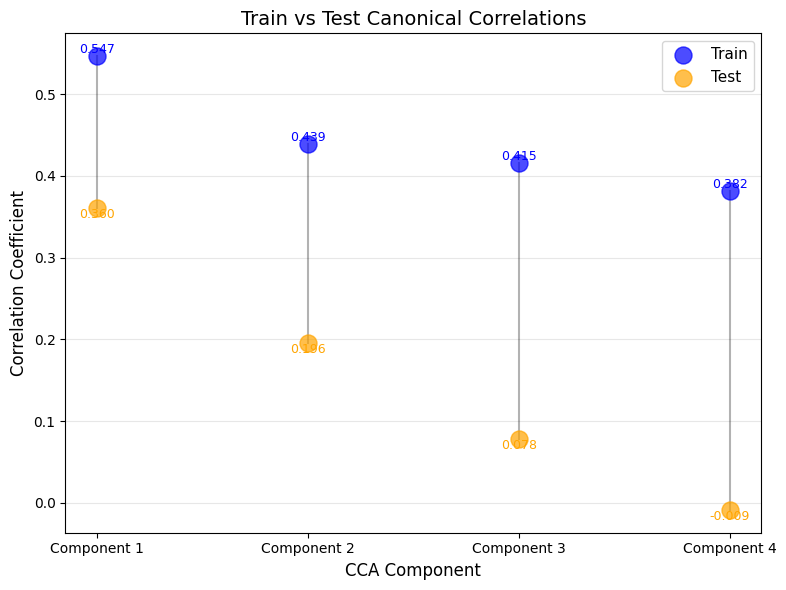

In [80]:
# Visualize correlation comparison with vertically aligned dots
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(correlations_train))

# Plot dots for train and test
ax.scatter(x, correlations_train, s=150, c='blue', alpha=0.7, label='Train', zorder=3)
ax.scatter(x, correlations_test, s=150, c='orange', alpha=0.7, label='Test', zorder=3)

# Connect train and test dots with lines
for i in range(len(correlations_train)):
    ax.plot([i, i], [correlations_train[i], correlations_test[i]], 
            'k-', alpha=0.3, linewidth=1.5, zorder=2)

ax.set_xlabel('CCA Component', fontsize=12)
ax.set_ylabel('Correlation Coefficient', fontsize=12)
ax.set_title('Train vs Test Canonical Correlations', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'Component {i+1}' for i in range(len(correlations_train))])
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')
# ax.set_ylim(0, max(max(correlations_train), max(correlations_test)) * 1.1)

# Add value labels
for i, (train_val, test_val) in enumerate(zip(correlations_train, correlations_test)):
    ax.text(i, train_val, f'{train_val:.3f}', ha='center', va='bottom', fontsize=9, color='blue')
    ax.text(i, test_val, f'{test_val:.3f}', ha='center', va='top', fontsize=9, color='orange')

plt.tight_layout()
plt.show()

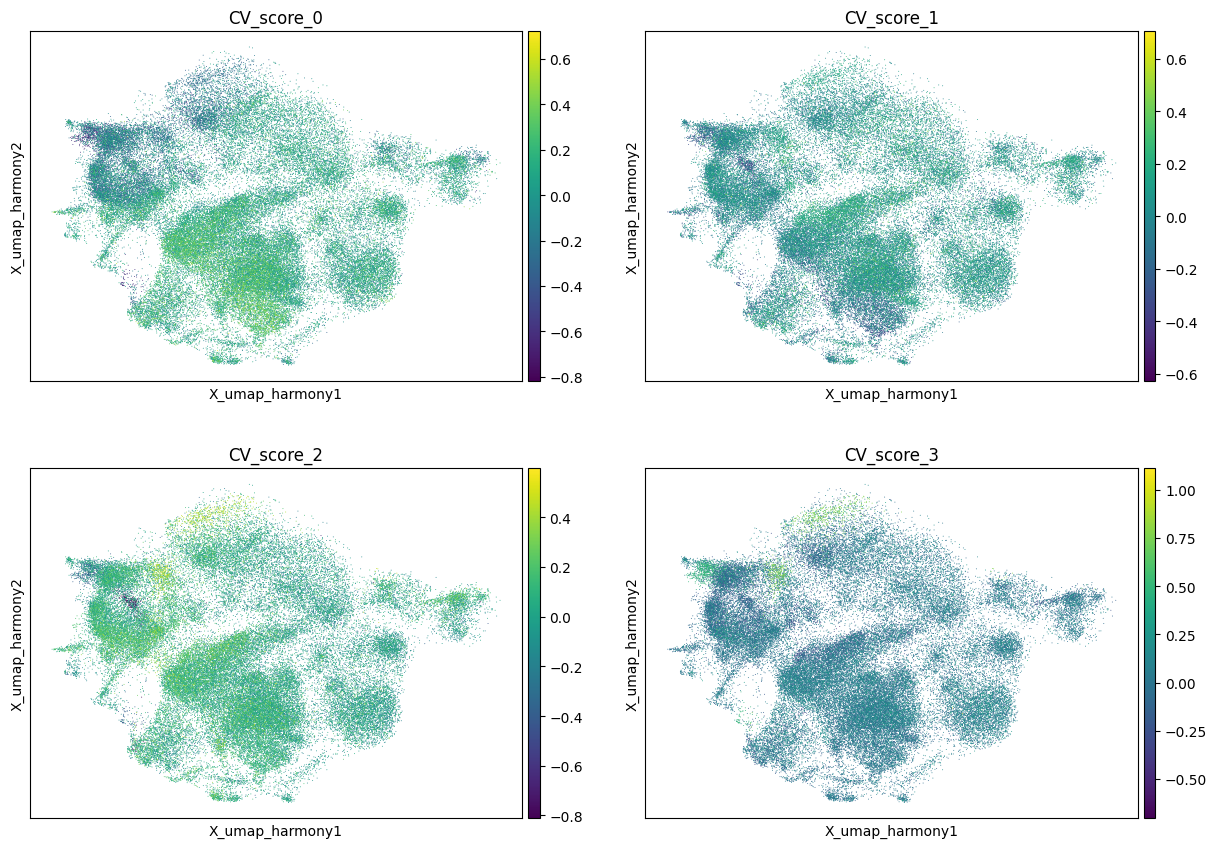

In [81]:
sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
            color= cv_list, ncols=2,)

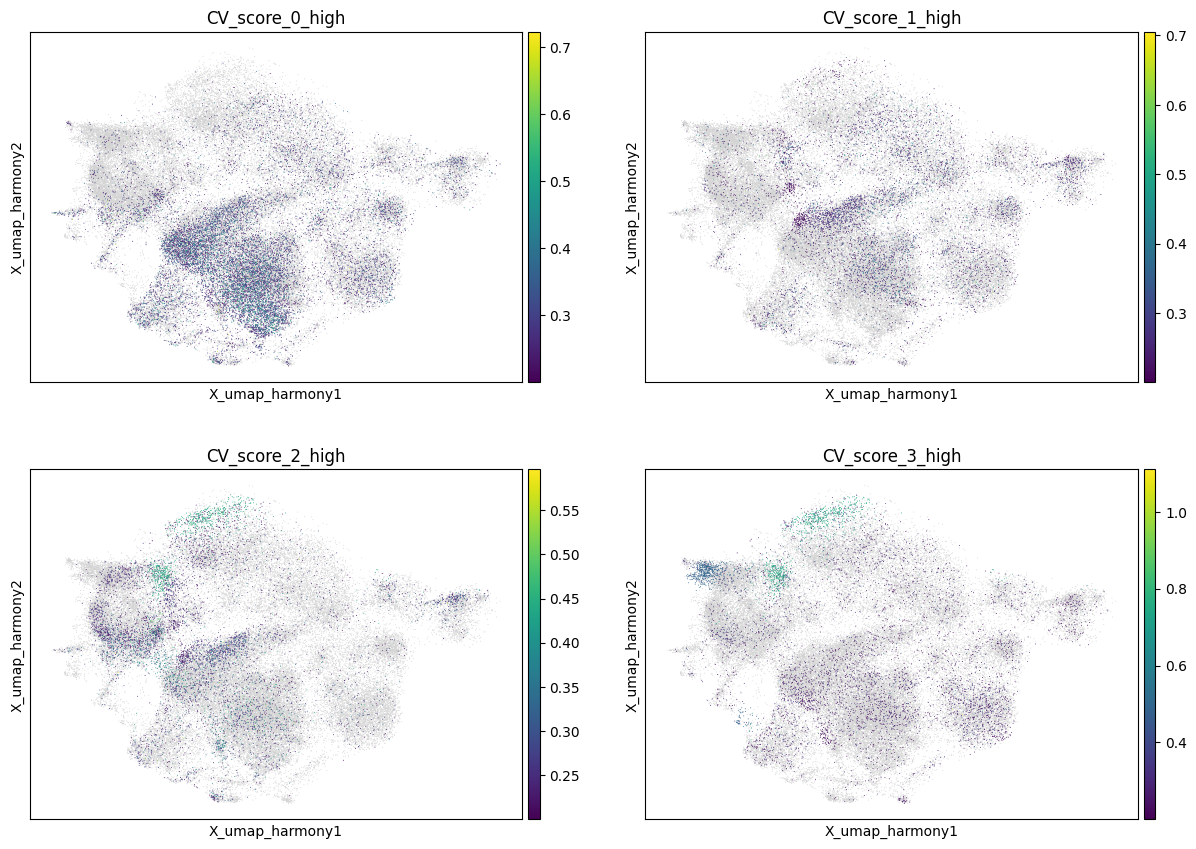

In [89]:
highlight_list = []
cutoff = 0.2
for i in range(0, 4):
    cv_name = f'CV_score_{i}'
    tmp_col = cv_name + "_high"
    highlight_list.append(tmp_col)
    
    vals = mdata['gex'].obs[cv_name].copy()
    # mdata['gex'].obs[tmp_col] = np.where(abs(vals) > cutoff, vals, np.nan)
    mdata['gex'].obs[tmp_col] = np.where(vals > cutoff, vals, np.nan)

sc.pl.embedding(mdata["gex"], basis = gene_Umap, neighbors_key = 'neighbors_harmony', 
            color= highlight_list, ncols=2,)

In [90]:
## correlation 
abs_target = ['tissue', 'cell_type', 'state']
cv_thres_p = cutoff
cv_thres_n = -cutoff

# Loop through CV_score_1 to CV_score_4
all_results = []

for i in range(0, 4):
    cv_name = f'CV_score_{i}'
    
    # Get positive and negative subsets
    mdata_sub_pos = mdata[(mdata['gex'].obs[cv_name] > cv_thres_p)]
    mdata_sub_neg = mdata[(mdata['gex'].obs[cv_name] < cv_thres_n)]
    
    # Filter for Spleen or CNS tissue only
    mdata_sub_pos_filtered = mdata_sub_pos[mdata_sub_pos['gex'].obs['tissue'].isin(['Spleen', 'CNS'])]
    mdata_sub_neg_filtered = mdata_sub_neg[mdata_sub_neg['gex'].obs['tissue'].isin(['Spleen', 'CNS'])]
    
    # Calculate percentages for positive subset
    percentage_dict = {'CV_component': cv_name}
    
    for col in abs_target:
        counts = mdata_sub_pos_filtered['gex'].obs[col].value_counts()
        percentages = (counts / len(mdata_sub_pos_filtered) * 100).round(2)
        for category, pct in percentages.items():
            col_name = f'pos_{category}'
            percentage_dict[col_name] = pct
    
    # Calculate percentages for negative subset
    for col in abs_target:
        counts = mdata_sub_neg_filtered['gex'].obs[col].value_counts()
        percentages = (counts / len(mdata_sub_neg_filtered) * 100).round(2)
        for category, pct in percentages.items():
            col_name = f'neg_{category}'
            percentage_dict[col_name] = pct
    
    all_results.append(percentage_dict)

df_CV = pd.DataFrame(all_results)
df_CV
    
# labels = mdata.obs["state"]
# label_bin = (mdata.obs["state"] == 'CNS').astype(int)

,CV_component,pos_CNS,pos_Spleen,pos_CD4,pos_Treg,pos_Th17,pos_CD8,pos_Activation,pos_Exhaust,pos_IFN_stim,...,neg_CNS,neg_Spleen,neg_CD8,neg_CD4,neg_Treg,neg_Th17,neg_Exhaust,neg_Mem_Naive,neg_IFN_stim,neg_Activation
0,CV_score_0,75.10,24.90,37.86,8.61,6.92,6.90,18.47,11.95,4.59,...,91.45,8.55,69.37,7.80,4.20,0.76,17.96,7.40,6.48,4.78
1,CV_score_1,48.21,51.79,20.86,9.23,3.32,13.09,10.13,4.87,5.41,...,80.43,19.57,19.17,36.87,4.82,6.50,25.62,0.94,3.58,12.01
2,CV_score_2,73.97,26.03,10.82,3.07,2.05,48.91,5.97,4.92,5.63,...,71.57,28.43,9.53,34.21,15.69,3.53,22.02,3.28,5.30,13.16
3,CV_score_3,71.52,28.48,16.87,12.81,2.17,33.33,9.99,6.91,4.79,...,72.25,27.75,40.62,19.89,3.07,2.31,19.06,2.07,5.52,6.60


# correlations

In [91]:
# ANOVA tests: comparing all groups within each abs_target
from scipy.stats import f_oneway

anova_results = []

for i in range(0,4):
    cv_name = f'CV_score_{i}'
    
    for col in abs_target:
        # Get unique categories
        categories = mdata['gex'].obs[col].dropna().unique()
        
        # Collect all groups for this variable
        groups = []
        for cat in categories:
            group_data = mdata['gex'].obs[mdata['gex'].obs[col] == cat][cv_name].dropna().values
            if len(group_data) > 0:
                groups.append(group_data)
        
        # Perform ANOVA comparing all groups
        if len(groups) > 1:
            f_stat, p_value = f_oneway(*groups)
            
            anova_results.append({
                'CV_component': cv_name,
                'variable': col,
                'n_groups': len(groups),
                'F_statistic': round(f_stat, 4),
                'p_value': f'{p_value:.4e}',
                'significant': 'Yes' if p_value < 0.05 else 'No'
            })

df_anova = pd.DataFrame(anova_results)
# df_anova


In [92]:
# Calculate Pearson correlation between marker genes and CV scores
from scipy.stats import pearsonr
import seaborn as sns
    
def pearson_corr(adata, var1, markers, var_type='gene'):
    corr_results = []
    
    for cv_name in var1:
        cv_scores = adata.obs[cv_name].values

        for gene in markers:
            if gene in adata.var_names or gene in adata.obs:
                if var_type =='gene':
                    # Get gene expression values
                    gene_expr = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten()
                
                if var_type =='obs':
                    # Get gene set scores
                    gene_expr = gene_expr = adata.obs[gene].to_numpy().flatten() 

                # Calculate Pearson correlation
                corr, p_value = pearsonr(gene_expr, cv_scores)

                corr_results.append({
                    'CV_component': cv_name,
                    'gene': gene,
                    'pearson_r': round(corr, 4),
                    'p_value': f'{p_value:.4e}',
                    'significant': 'Yes' if p_value < 0.05 else 'No'
                })
            else:
                print(f"Warning: Input '{gene}' not found in dataset")

    df_gene_corr = pd.DataFrame(corr_results)
    corr_matrix = df_gene_corr.pivot(index='CV_component', columns='gene', values='pearson_r')
    return corr_matrix
    
    

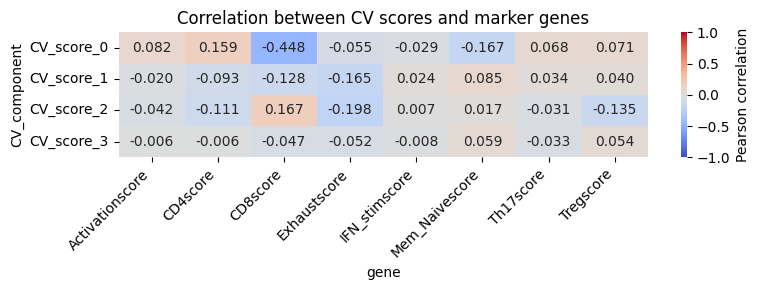

In [93]:
# Create the heatmap
cv_obs_name = [f'CV_score_{i}' for i in range(4)]
scores = ['CD4score', 'CD8score', 'Tregscore', 'Th17score',
          'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore',]

corr_matrix_obs = pearson_corr(mdata['gex'], cv_obs_name, scores, var_type='obs')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_obs, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and marker genes')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

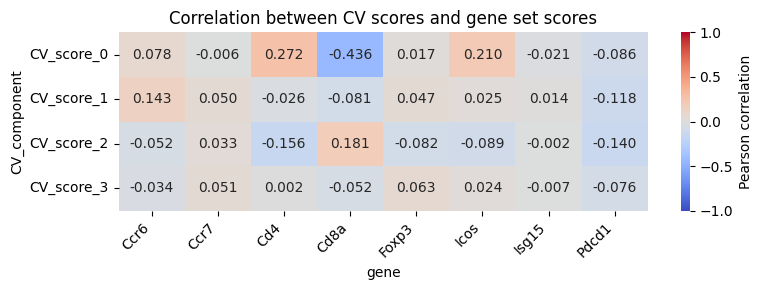

In [94]:
marker_genes = ['Cd4','Cd8a', 'Foxp3', 'Ccr6', 'Il17', 'Isg15', 'Icos', 'Pdcd1', 'Ccr7']
corr_matrix_genes = pearson_corr(mdata['gex'], cv_obs_name, marker_genes, var_type='gene')

plt.figure(figsize=(8, 3))
sns.heatmap(corr_matrix_genes, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, fmt='.3f', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation between CV scores and gene set scores')
plt.xticks(rotation=45, ha='right')   # horizontal alignment
plt.yticks(rotation=0) 
plt.tight_layout()
plt.show()

# Save

In [95]:
# import anndata as ad
# ad.settings.allow_write_nullable_strings = True
# mdata.write('merged_EAE_TCRemb.h5mu')